<a href="https://colab.research.google.com/github/Marina202005/ML-Seminar_HorhoceaMarina/blob/main/Tema_Laborator_2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercițiu LP2 — Setul de date Penguins

**de lucru individual — aprox. 30 minute**

Ați exersat în LP2 explorarea structurii datelor, curățarea lor, statisticile descriptive și principalele tipuri de grafice, pe setul de date Galton. În acest exercițiu aplicați aceleași tehnici pe un set de date nou: **Palmer Penguins** — măsurători pentru 344 de pinguini din trei specii, colectate în Arhipelagul Palmer, Antarctica.

**Variabile:**
- `species` — specia pinguinului: Adelie, Chinstrap sau Gentoo
- `island` — insula pe care a fost observat: Biscoe, Dream sau Torgersen
- `bill_length_mm`, `bill_depth_mm` — lungimea și adâncimea ciocului (mm)
- `flipper_length_mm` — lungimea aripioarei (mm)
- `body_mass_g` — masa corporală (g)
- `sex` — sexul pinguinului

### Instrucțiuni
- Lucrați **individual**, timp de aproximativ 30 de minute.
- Completați celulele marcate cu `# TODO`, folosind comenzile exersate în LP2.
- Nu este nevoie să scrieți cod perfect — scopul e să exersați, nu să obțineți un rezultat impecabil.
- Dacă rămâneți blocați mai mult de 4-5 minute la o cerință, treceți la următoarea și reveniți la final.

### Pregătire — rulați celula de mai jos (nu necesită modificări)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

penguins_df = sns.load_dataset('penguins')
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Sarcina 1 — Explorarea structurii datelor (~5 min)

**1.1** Afișați dimensiunea setului de date (număr de rânduri și coloane).

In [3]:
# TODO 1.1
penguins_df.shape

(344, 7)

**1.2** Afișați tipul de date al fiecărei coloane.

In [4]:
# TODO 1.2
penguins_df.dtypes

,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object


**1.3** Afișați un rezumat descriptiv pentru **toate** variabilele (numerice și categoriale).

In [5]:
# TODO 1.3
penguins_df.describe(include='all')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,Male
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


**1.4** Câte specii distincte de pinguini există în setul de date? Care sunt ele? *(indiciu: `nunique()` și `unique()`)*

In [7]:
# TODO 1.4
penguins_df['species'].nunique()
penguins_df['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

## Sarcina 2 — Manipularea datelor (~5 min)

**2.1** Selectați și afișați doar coloanele `species`, `island` și `body_mass_g`.

In [8]:
# TODO 2.1
penguins_df[['species', 'island', 'body_mass_g']]

,species,island,body_mass_g
0,Adelie,Torgersen,3750.0
1,Adelie,Torgersen,3800.0
2,Adelie,Torgersen,3250.0
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,3450.0
...,...,...,...
339,Gentoo,Biscoe,NaN
340,Gentoo,Biscoe,4850.0
341,Gentoo,Biscoe,5750.0
342,Gentoo,Biscoe,5200.0


**2.2** Filtrați setul de date pentru a păstra doar pinguinii din specia `Gentoo`. Salvați rezultatul într-o variabilă nouă, `gentoo_df`.

In [9]:
# TODO 2.2
gentoo_df = penguins_df[penguins_df['species'] == 'Gentoo']

gentoo_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
220,Gentoo,Biscoe,46.1,13.2,211.0,4500.0,Female
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,Male
222,Gentoo,Biscoe,48.7,14.1,210.0,4450.0,Female
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,Male
224,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,Male
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


**2.3** Selectați un eșantion aleator de 10 rânduri din setul de date original.

In [10]:
# TODO 2.3
penguins_df.sample(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
290,Gentoo,Biscoe,47.7,15.0,216.0,4750.0,Female
239,Gentoo,Biscoe,48.7,15.1,222.0,5350.0,Male
178,Chinstrap,Dream,50.5,18.4,200.0,3400.0,Female
123,Adelie,Torgersen,41.4,18.5,202.0,3875.0,Male
308,Gentoo,Biscoe,47.5,14.0,212.0,4875.0,Female
145,Adelie,Dream,39.0,18.7,185.0,3650.0,Male
35,Adelie,Dream,39.2,21.1,196.0,4150.0,Male
330,Gentoo,Biscoe,50.5,15.2,216.0,5000.0,Female
128,Adelie,Torgersen,39.0,17.1,191.0,3050.0,Female
44,Adelie,Dream,37.0,16.9,185.0,3000.0,Female


## Sarcina 3 — Curățarea datelor (~5 min)

**3.1** Câte valori lipsă (`NaN`) are fiecare coloană?

In [11]:
# TODO 3.1
penguins_df.isna().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


**3.2** Eliminați rândurile cu valori lipsă și salvați rezultatul într-un nou DataFrame, `penguins_clean`.

In [12]:
# TODO 3.2
penguins_clean = penguins_df.dropna()

penguins_clean

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


**3.3** Verificați dimensiunea noului set de date. Câte rânduri au fost eliminate față de setul inițial?

In [13]:
# TODO 3.3
print("Dimensiunea inițială:", penguins_df.shape)
print("Dimensiunea după curățare:", penguins_clean.shape)

print("Număr de rânduri eliminate:",
      len(penguins_df) - len(penguins_clean))

Dimensiunea inițială: (344, 7)
Dimensiunea după curățare: (333, 7)
Număr de rânduri eliminate: 11


## Sarcina 4 — Statistici descriptive (~7 min)

*Folosiți `penguins_clean` pentru sarcinile de mai jos.*

**4.1** Calculați masa corporală medie (`body_mass_g`), pentru fiecare specie.

In [16]:
# TODO 4.1
penguins_clean.groupby('species')['body_mass_g'].mean()

,body_mass_g
species,
Adelie,3706.164384
Chinstrap,3733.088235
Gentoo,5092.436975


**4.2** Care specie are, în medie, cea mai lungă aripioară (`flipper_length_mm`)?

In [17]:
# TODO 4.2
flipper_mean = penguins_clean.groupby('species')['flipper_length_mm'].mean()

flipper_mean

,flipper_length_mm
species,
Adelie,190.102740
Chinstrap,195.823529
Gentoo,217.235294


**4.3** Afișați frecvența (numărul de observații) pentru fiecare insulă (`island`).

In [18]:
# TODO 4.3
penguins_clean['island'].value_counts()

,count
island,
Biscoe,163
Dream,123
Torgersen,47


**4.4** Ce procent din pinguini sunt masculi și ce procent sunt femele, în setul curățat? *(indiciu: `value_counts(normalize=True)`)*

In [19]:
# TODO 4.4
penguins_clean['sex'].value_counts(normalize=True) * 100

,proportion
sex,
Male,50.45045
Female,49.54955


## Sarcina 5 — Vizualizare (~8 min)

*Folosiți `penguins_clean` pentru graficele de mai jos.*

**5.1** Realizați un `countplot` pentru distribuția speciilor (`species`).

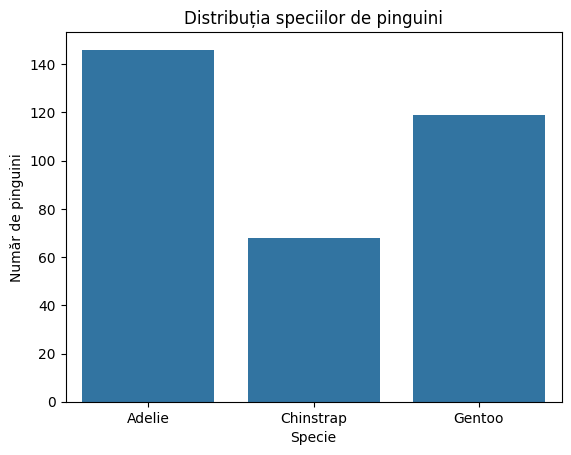

In [20]:
# TODO 5.1
sns.countplot(data=penguins_clean, x='species')

plt.title('Distribuția speciilor de pinguini')
plt.xlabel('Specie')
plt.ylabel('Număr de pinguini')
plt.show()

**5.2** Realizați un `barplot` cu masa corporală medie pe specie, colorat (`hue`) în funcție de sex.

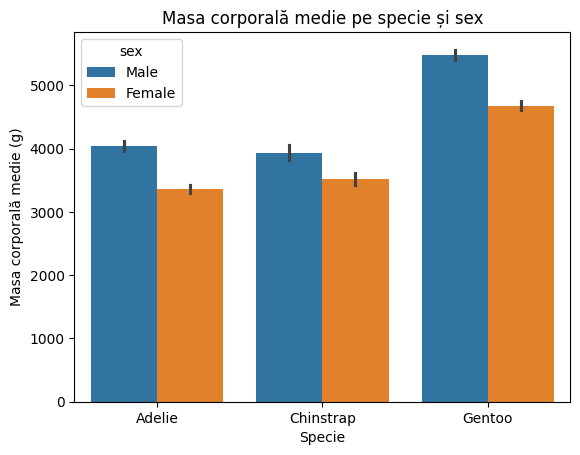

In [21]:
# TODO 5.2
sns.barplot(
    data=penguins_clean,
    x='species',
    y='body_mass_g',
    hue='sex'
)

plt.title('Masa corporală medie pe specie și sex')
plt.xlabel('Specie')
plt.ylabel('Masa corporală medie (g)')
plt.show()

**5.3** Realizați un grafic de tip `relplot` (scatter) între `bill_length_mm` și `bill_depth_mm`, colorat după `species`.

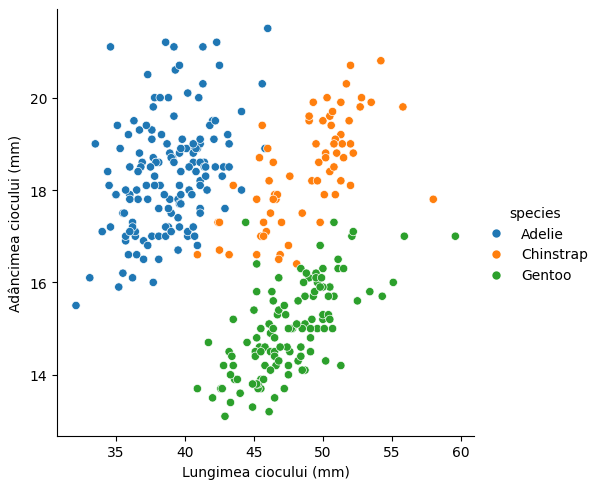

In [22]:
# TODO 5.3
sns.relplot(
    data=penguins_clean,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    kind='scatter'
)

plt.xlabel('Lungimea ciocului (mm)')
plt.ylabel('Adâncimea ciocului (mm)')
plt.show()

**5.4** Realizați un `boxplot` sau un `violinplot` (folosind `catplot`) pentru `flipper_length_mm`, pe fiecare specie.

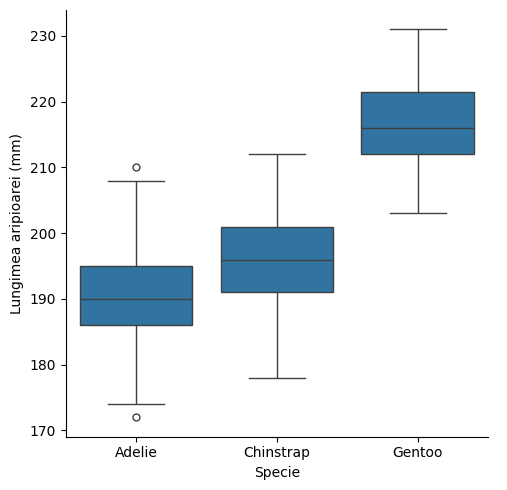

In [23]:
# TODO 5.4
sns.catplot(
    data=penguins_clean,
    x='species',
    y='flipper_length_mm',
    kind='box'
)

plt.xlabel('Specie')
plt.ylabel('Lungimea aripioarei (mm)')
plt.show()

**5.5** Realizați un `heatmap` cu matricea de corelații a variabilelor numerice.

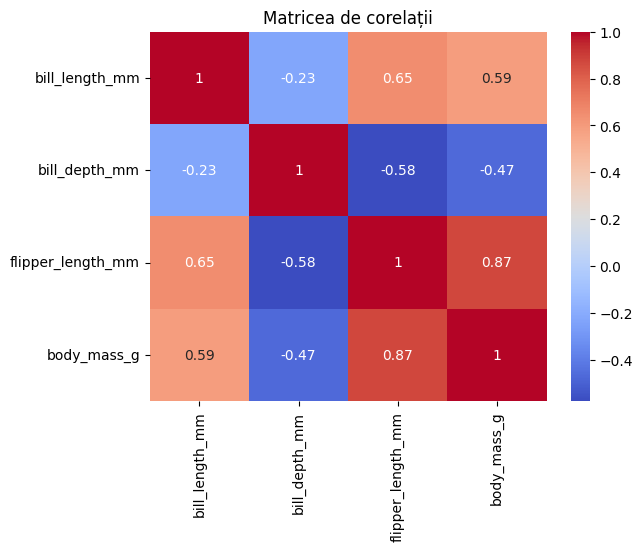

In [24]:
# TODO 5.5
corr = penguins_clean.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Matricea de corelații')
plt.show()

## Bonus (opțional, dacă ați terminat mai devreme)

- Există diferențe de masă corporală între insule (`island`)? Realizați un `barplot` sau un `boxplot` pentru a verifica.
- Realizați un `pairplot` cu `hue='species'` pentru întregul set curățat — ce observați?

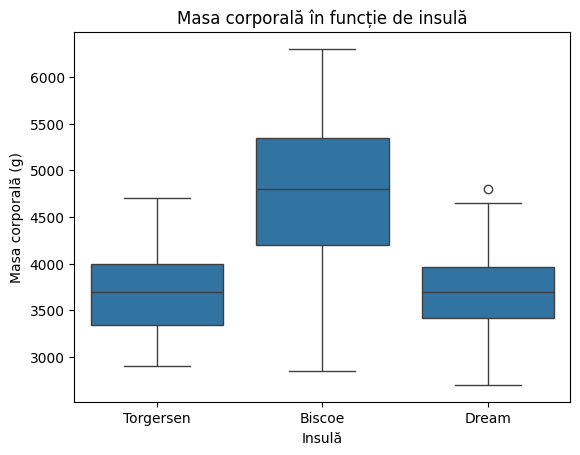

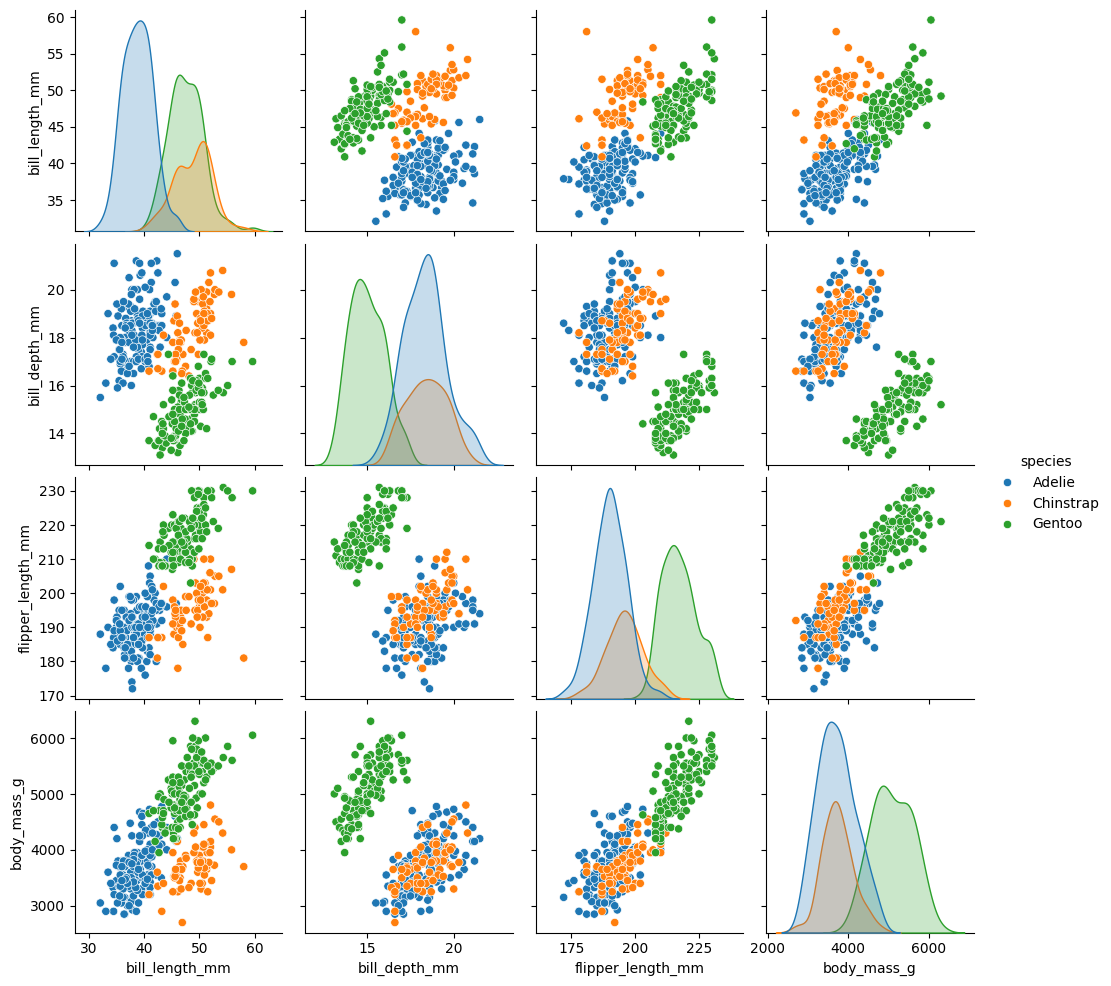

In [26]:
# Bonus — opțional
sns.boxplot(
    data=penguins_clean,
    x='island',
    y='body_mass_g'
)

plt.title('Masa corporală în funcție de insulă')
plt.xlabel('Insulă')
plt.ylabel('Masa corporală (g)')
plt.show()

sns.pairplot(
    penguins_clean,
    hue='species'
)

plt.show()